In [1]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

import cns
import cns.data_utils as cdu
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

C:\Users\adams\AppData\Local\Temp\ipykernel_42876\1736925853.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [6]:
list(plt.cm.get_cmap('tab10').colors[:10]) + [(0,0,0)]

C:\Users\adams\AppData\Local\Temp\ipykernel_42876\1523643244.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  list(plt.cm.get_cmap('tab10').colors[:10]) + [(0,0,0)]


[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529),
 (0, 0, 0)]

In [2]:
cns_dfs = {}
for grouping in ["whole", "arms", "20MB", "10MB", "5MB", "3MB", "1MB", "500KB", "250KB", "100KB"]:
	print(f"Loading {grouping}...")
	samples_df, cns_df = cdu.main_load(grouping)
	cns.only_aut(cns_df, inplace=True)
	cns.add_total_cn(cns_df, inplace=True)
	cns_dfs[grouping] = cns_df
samples_df["type"].value_counts().head()

Loading whole...
Loading arms...
Loading 20MB...
Loading 10MB...
Loading 5MB...
Loading 3MB...
Loading 1MB...
Loading 500KB...
Loading 250KB...
Loading 100KB...


type
LUAD    1314
BRCA    1157
LUSC     996
OV       618
PRAD     563
Name: count, dtype: int64

In [3]:
cosmic = cdu.load_COSMIC()
cosmic_df = cns.segments_to_cns_df(cosmic)[["chrom", "start", "end", "name"]].rename(columns={"name": "gene"})
ensembl = cdu.load_ENSEMBL()
cancer_type = "all"
val_count = 5

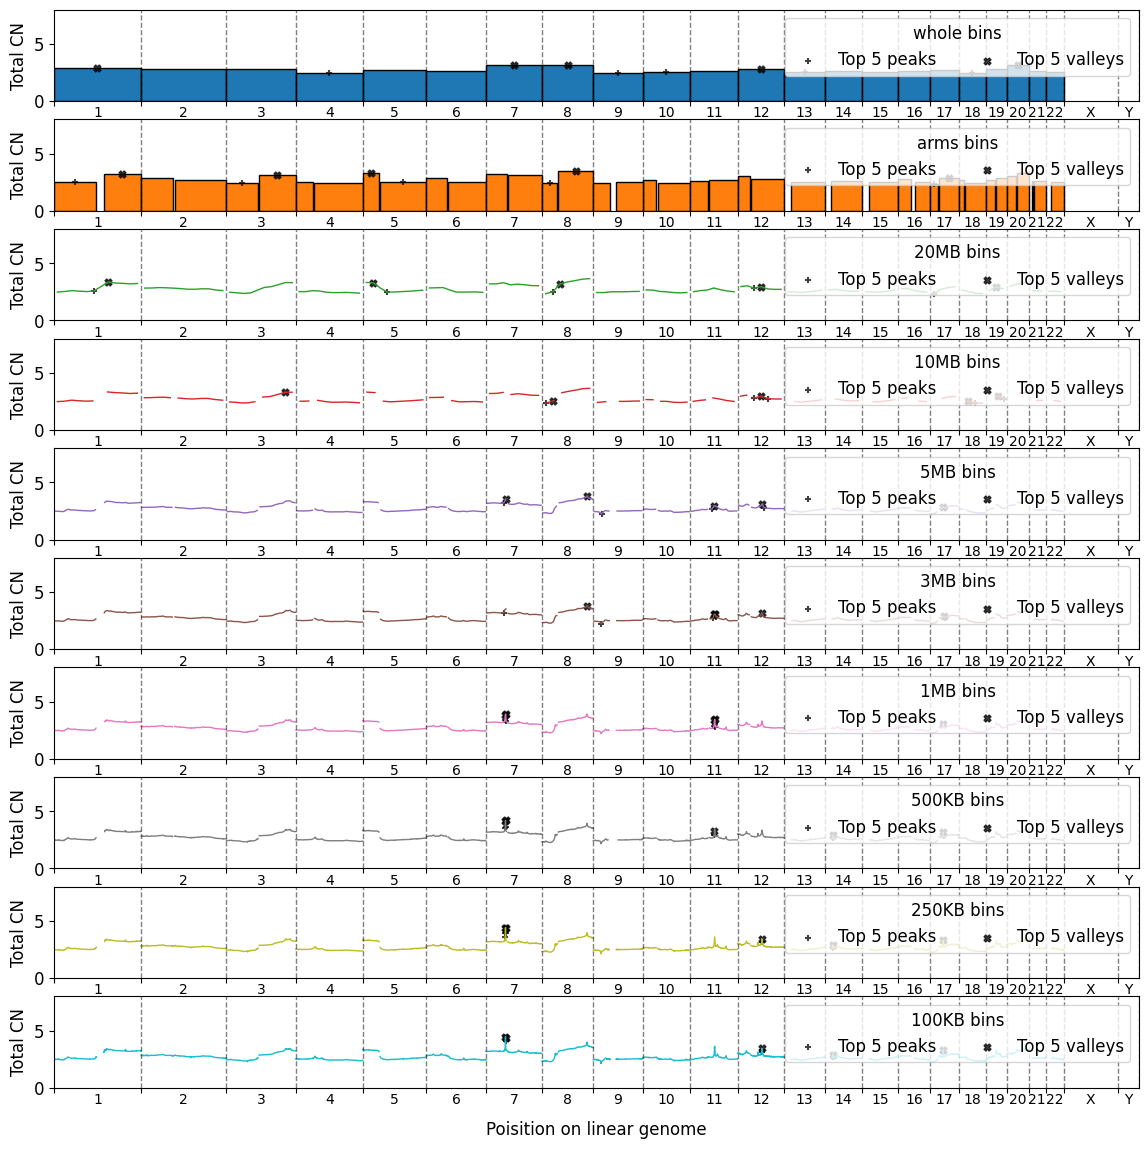

In [4]:
fig, axs = plt.subplots(len(cns_dfs), 1, figsize=(14, 14))

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	sel_df = cns.select_cns_by_type(cns_df, samples_df, cancer_type) if cancer_type != "all" else cns_df
	group_df = cns.group_samples(cns.only_aut(cns.add_total_cn(sel_df)))
	group_df["sample_id"] = f"mean {cancer_type} CN"
	group_df = cns.add_cum_mid(group_df)
	if grouping == "whole":
		group_by = "sample"
	elif grouping == "arms":
		group_by = "chrom"
	else:
		group_by = "cons"
	group_df["score"] = cns.calc_angles(group_df, "total_cn", group_by=group_by)

	if grouping == "whole" or grouping == "arms":
		cns.plot_bars(axs[i], group_df, cn_column="total_cn", color=color_map[i])
	else:
		cns.plot_lines(axs[i], group_df, cn_column="total_cn", color=color_map[i])
	cns.plot_x_lines(axs[i])
	cns.plot_x_ticks(axs[i])

	group_df = group_df.sort_values(by="score")
	axs[i].scatter(group_df["cum_mid"].head(val_count), group_df["total_cn"].head(val_count), color="k", alpha=0.75, s=25, label=f"Top {val_count} peaks", marker="+")
	axs[i].scatter(group_df["cum_mid"].tail(val_count), group_df["total_cn"].tail(val_count), color="k", alpha=0.75, s=25, label=f"Top {val_count} valleys", marker="X")
	axs[i].set_ylim(0, 8)
	axs[i].set_ylabel("Total CN")
	axs[i].legend(title=f"{grouping} bins", loc="upper right", ncol=3)

axs[-1].set_xlabel("Poisition on linear genome")

cdu.save_cns_fig(f"peaks_valleys_{cancer_type}")

In [5]:
score_means = []

def get_gouping_type(bins):
	if bins == "whole":
		return "sample"
	elif bins == "arms":
		return "chrom"
	else:
		return "cons"

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	print(f"Loading {grouping}...")
	sel_df = cns.select_cns_by_type(cns_df, samples_df, cancer_type) if cancer_type != "all" else cns_df
	sel_df = cns.group_samples(cns.only_aut(cns.add_total_cn(sel_df)))
	sel_df["sample_id"] = f"mean {cancer_type} CN"
	sel_df["score"] = cns.calc_angles(sel_df, "total_cn", get_gouping_type(grouping))	
	score_means.append(cns.mean_value_per_seg(sel_df, ensembl, "score"))

mean_dfs = {}
mean_df = score_means[0].copy()
for vals in score_means[1:]:
	mean_df["score"] += vals["score"]
mean_df["score"] /= len(score_means)
mean_df["total_cn"] = cns.mean_value_per_seg(sel_df, ensembl, "total_cn")["total_cn"]
mean_df = pd.merge(mean_df, cosmic_df, how="left")

cns.save_cns(mean_df, cdu.pjoin(cdu.out_path, f"gene_scores_{cancer_type}.tsv"))

In [6]:
print(mean_df[~mean_df["gene"].isna()].sort_values(by="score", ascending=False).head(10))

       chrom      start        end             name     score  total_cn  \
17294   chr7   55086713   55324313  ENSG00000146648  0.326843  4.426993   
8252   chr17   37844166   37886679  ENSG00000141736  0.293176  3.342424   
4824   chr12   69201955   69239214  ENSG00000135679  0.262844  3.473770   
18498   chr8  128747679  128753674  ENSG00000136997  0.246986  3.993505   
8255   chr17   37921197   38020441  ENSG00000161405  0.241034  3.200131   
18207   chr8   54879111   54935089  ENSG00000187735  0.184599  3.250458   
18221   chr8   57124244   57131357  ENSG00000170791  0.183121  3.262937   
18220   chr8   57073462   57123883  ENSG00000181690  0.182976  3.262937   
18217   chr8   56792371   56923940  ENSG00000254087  0.180967  3.259649   
9845   chr19   30302804   30315215  ENSG00000105173  0.177509  3.295924   

         gene  
17294    EGFR  
8252    ERBB2  
4824     MDM2  
18498     MYC  
8255    IKZF3  
18207   TCEA1  
18221  CHCHD7  
18220   PLAG1  
18217     LYN  
9845    CCNE1 

In [7]:
print(mean_df.sort_values(by="score", ascending=False).head(10))

       chrom     start       end             name     score  total_cn   gene
17294   chr7  55086713  55324313  ENSG00000146648  0.326843  4.426993   EGFR
8254   chr17  37894179  37903544  ENSG00000141738  0.293176  3.342424    NaN
8250   chr17  37824233  37826728  ENSG00000141744  0.293176  3.342424    NaN
8251   chr17  37827374  37853050  ENSG00000161395  0.293176  3.342424    NaN
8252   chr17  37844166  37886679  ENSG00000141736  0.293176  3.342424  ERBB2
8253   chr17  37884748  37887040  ENSG00000141741  0.293176  3.342424    NaN
8246   chr17  37759788  37766030  ENSG00000171532  0.278478  3.273670    NaN
8247   chr17  37782992  37792879  ENSG00000131771  0.278478  3.273670    NaN
8248   chr17  37793317  37819737  ENSG00000131748  0.278478  3.273670    NaN
8249   chr17  37820439  37822808  ENSG00000173991  0.278478  3.273670    NaN


We therefore focused on relative effects: when applied to the COSMIC gene set (i.e. where cancer effect is already expected), our method determines the top 5 genes to be FADD (OS=1.53), CCND1 (OS=1.22), FGFR1 (OS=0.94), SOX2 (OS=0.65), and EGFR (OS=0.46). 

In [13]:

ordered_df = mean_df.sort_values(by=["score"], ascending=False)
ordered_df["score"].sum()
tsgs_df = ordered_df.query("score < 0")[["chrom", "start", "end", "name", "score"]].copy()
tsgs_df["score"] = -tsgs_df["score"]
print(tsgs_df["score"].describe())
print(tsgs_df["score"].sum())
tsgs_df.to_csv(cdu.pjoin(cdu.out_path, f"tsgs_cnsistent_all.tsv"), sep="\t", index=False, header=False)
tsgs_df[-1000:].to_csv(cdu.pjoin(cdu.out_path, f"tsgs_cnsistent_1000.tsv"), sep="\t", index=False, header=False)

ogs_df = ordered_df.query("score >= 0")[["chrom", "start", "end", "name", "score"]].copy()
print(ogs_df["score"].describe())
print(ogs_df["score"].sum())
# ogs_df["score"] = ogs_df["score"] / ogs_df["score"].sum() * tsgs_df["score"].sum()
# print(ogs_df["score"].describe())
# print(ogs_df["score"].sum())
ogs_df.to_csv(cdu.pjoin(cdu.out_path, f"ogs_cnsistent_all.tsv"), sep="\t", index=False, header=False)
ogs_df[:1000].to_csv(cdu.pjoin(cdu.out_path, f"ogs_cnsistent_1000.tsv"), sep="\t", index=False, header=False)

count    11316.000000
mean         0.037880
std          0.026509
min          0.000008
25%          0.016931
50%          0.033395
75%          0.053684
max          0.133392
Name: score, dtype: float64
428.6522223498861
count    8114.000000
mean        0.056151
std         0.046096
min         0.000004
25%         0.017180
50%         0.047197
75%         0.080926
max         0.326843
Name: score, dtype: float64
455.6083892156662


In [11]:
ogs_df[:1000]

,chrom,start,end,name,score
17294,chr7,55086713,55324313,ENSG00000146648,0.326843
8254,chr17,37894179,37903544,ENSG00000141738,0.293176
8250,chr17,37824233,37826728,ENSG00000141744,0.293176
8251,chr17,37827374,37853050,ENSG00000161395,0.293176
8252,chr17,37844166,37886679,ENSG00000141736,0.293176
...,...,...,...,...,...
1409,chr1,158532440,158533394,ENSG00000186440,0.124355
1408,chr1,158516917,158517895,ENSG00000197532,0.124355
1410,chr1,158548708,158549689,ENSG00000186400,0.124355
1391,chr1,157090982,157108266,ENSG00000117036,0.124104
